# Part I: Surface Construction (M2)

From per-minute option quotes to a one-minute implied-volatility surface on a
fixed (DTE bucket x log-moneyness) grid: 9 DTE buckets x 14 log-moneyness
nodes = 126 cells per minute. Per snapshot the builder fits SVI slices per
expiry with quality gating, recovers forwards from put-call parity, solves
Black-76 IVs and Greeks, and writes quality flags alongside every value.

Two demonstrations here: (1) the builder runs end to end on the committed
one-hour sample; (2) the full-day production artifacts (built data-local,
pulled to the research checkout) drive the visuals.

In [1]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The research library and data live in the (private) qfdev_research repo,
# checked out as a sibling of this showcase repo. Override with QFDEV_RESEARCH.
RESEARCH = os.path.abspath(os.environ.get('QFDEV_RESEARCH', '../../qfdev_research'))
assert os.path.isdir(os.path.join(RESEARCH, 'quant')), RESEARCH
sys.path.insert(0, RESEARCH)

plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.width', 160)

import tempfile, warnings
warnings.filterwarnings('ignore')
from quant.surface import build

SAMPLE_ROOT = os.path.join(RESEARCH, 'quant', 'surface', 'sample')
# Scratch output dir (kept relative so logs stay machine-independent).
tmp = os.path.relpath(tempfile.mkdtemp(prefix='surface_demo_'))
snap, grid_s, metrics_s = build.run(symbol_day='spy_20260331',
                                    replay_root=SAMPLE_ROOT, out_root=tmp)
print('sample-hour build:', snap.shape[0], 'contract-minutes ->',
      grid_s.shape[0], 'grid rows,', metrics_s.shape[0], 'metric rows')

[   0.0s] loading contract universe...


[   0.0s] loading underlying 1-min spot...


[   1.7s]   universe: 5954 contracts in [1,45]+ DTE; 960 spot minutes


[   1.7s] reducing OPRA NBBO to per-minute last quotes (hour by hour)...


[  51.6s]   41761 (instrument, minute) quote rows


...

[  53.1s] building frozen-anchor vega-edge labels (contract-level)...


[  53.4s]   48329 labeled (contract, horizon) rows


[  53.6s] wrote artifacts to ..\..\..\..\..\..\AppData\Local\Temp\surface_demo_0aallwa1\spy_20260331

Part I - surface quality report
Contract-minutes                        27,482
  with valid IV                         23,147 (84.2%)
SVI slices fit                          120
SVI trusted rate                        100.0%
Fallback rate                           0.0%
Median slice fit RMSE (vol pts)         2.11
Median weighted fit RMSE (vol pts)      2.12
Mean surface quality score              0.578
Parity forward coverage                 100.0%
Spot fallback rate                      0.0%
Contracts labeled, 5m horizon           20,424
Contracts labeled, 15m horizon          16,728
Contracts labeled, 30m horizon          11,177
Mean label, fit_z top decile (15m)      -2.0269
Mean label, fit_z bottom decile (15m)   -0.4044
  -> top-minus-bottom spread            -1.6225


sample-hour build: 27482 contract-minutes -> 1680 grid rows, 120 metric rows


## Full-day surface state

One production symbol-day (all strikes, all expiries, full session). Each row
is one (minute, DTE bucket, log-moneyness node) cell with its IV, Greeks,
microstructure state, and fit-quality columns.

In [2]:
DAY = 'spy_20260616'
OUT = os.path.join(RESEARCH, 'quant', 'surface', 'out', DAY)
grid = pd.read_parquet(os.path.join(OUT, 'surface_state_1m.parquet'))
metrics = pd.read_parquet(os.path.join(OUT, 'surface_metrics_1m.parquet'))
print(f"{DAY}: {len(grid):,} cell-minutes | {grid['minute'].nunique()} minutes | "
      f"{grid['dte_bucket'].nunique()} DTE buckets x {grid['moneyness_bucket'].nunique()} k-nodes")
grid[['minute', 'dte_bucket', 'moneyness_bucket', 'iv', 'delta', 'spot',
      'svi_trusted', 'slice_fit_rmse']].head()

spy_20260616: 39,700 cell-minutes | 406 minutes | 7 DTE buckets x 14 k-nodes


,minute,dte_bucket,moneyness_bucket,iv,delta,spot,svi_trusted,slice_fit_rmse
0,2026-06-16 13:30:00+00:00,1,-0.060,0.740632,-0.005476,754.63,0,0.011229
1,2026-06-16 13:30:00+00:00,1,-0.045,0.615630,-0.011330,754.63,0,0.011229
2,2026-06-16 13:30:00+00:00,1,-0.035,0.454857,0.481516,754.63,0,0.011229
3,2026-06-16 13:30:00+00:00,1,-0.025,0.416587,0.452417,754.63,0,0.011229
4,2026-06-16 13:30:00+00:00,1,-0.015,0.367409,0.388810,754.63,0,0.011229


## The surface at one minute

Rows are DTE buckets, columns are log-moneyness. The grid coordinate is
**spot-based**: `k = log(K/spot)` exactly as written by the production
builder; the parity-recovered forwards feed Black-76 pricing and Greeks, not
the grid axis. Negative `k` = downside puts. The smile should rise into the wings and the term structure
should vary smoothly with DTE.

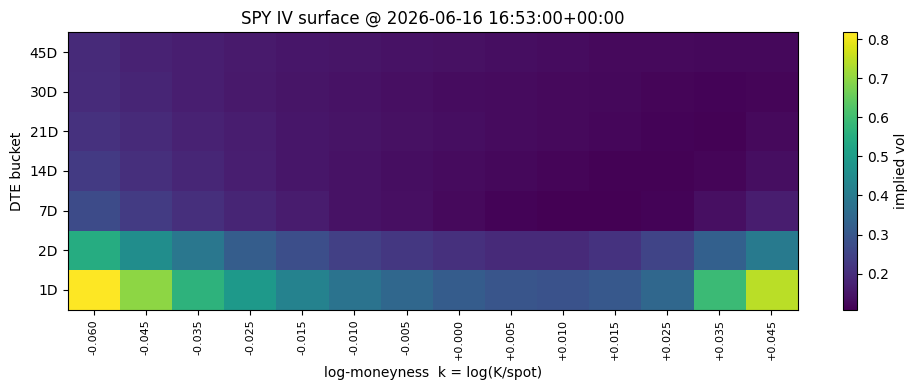

In [3]:
minutes = sorted(grid['minute'].unique())
t = minutes[len(minutes) // 2]
pivot = (grid[grid['minute'] == t]
         .pivot_table(index='dte_bucket', columns='moneyness_bucket', values='iv'))

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot.values, aspect='auto', origin='lower', cmap='viridis')
ax.set_xticks(range(len(pivot.columns)),
              [f'{c:+.3f}' for c in pivot.columns], rotation=90, fontsize=8)
ax.set_yticks(range(len(pivot.index)), [f'{int(i)}D' for i in pivot.index])
ax.set_xlabel('log-moneyness  k = log(K/spot)'); ax.set_ylabel('DTE bucket')
ax.set_title(f'SPY IV surface @ {pd.Timestamp(t)}')
fig.colorbar(im, ax=ax, label='implied vol')
plt.tight_layout()

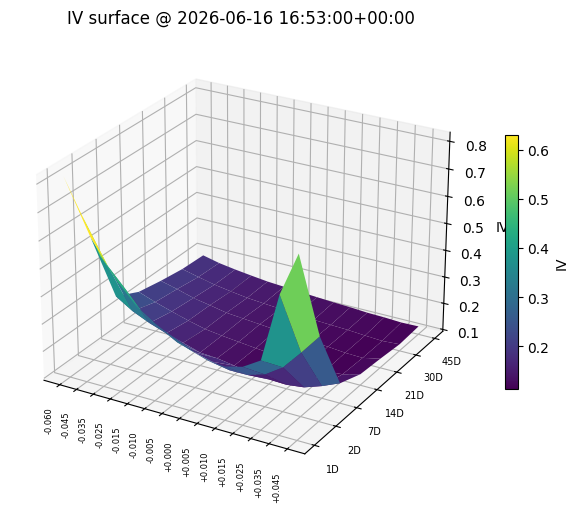

In [4]:
X, Y = np.meshgrid(np.arange(len(pivot.columns)), np.arange(len(pivot.index)))
fig = plt.figure(figsize=(8.5, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, pivot.values, cmap='viridis', edgecolor='none')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{c:+.3f}' for c in pivot.columns], rotation=90, fontsize=6)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'{int(i)}D' for i in pivot.index], fontsize=7)
ax.set_zlabel('IV'); ax.view_init(elev=25, azim=-60)
ax.set_title(f'IV surface @ {pd.Timestamp(t)}')
fig.colorbar(surf, shrink=0.55, label='IV')
plt.tight_layout()

## Intraday surface dynamics

Per-minute front-bucket metrics over the session. These are the quantities
Part II forecasts changes of: ATM level, the put-call wing spread (skew), and
the ATM term-structure slope.

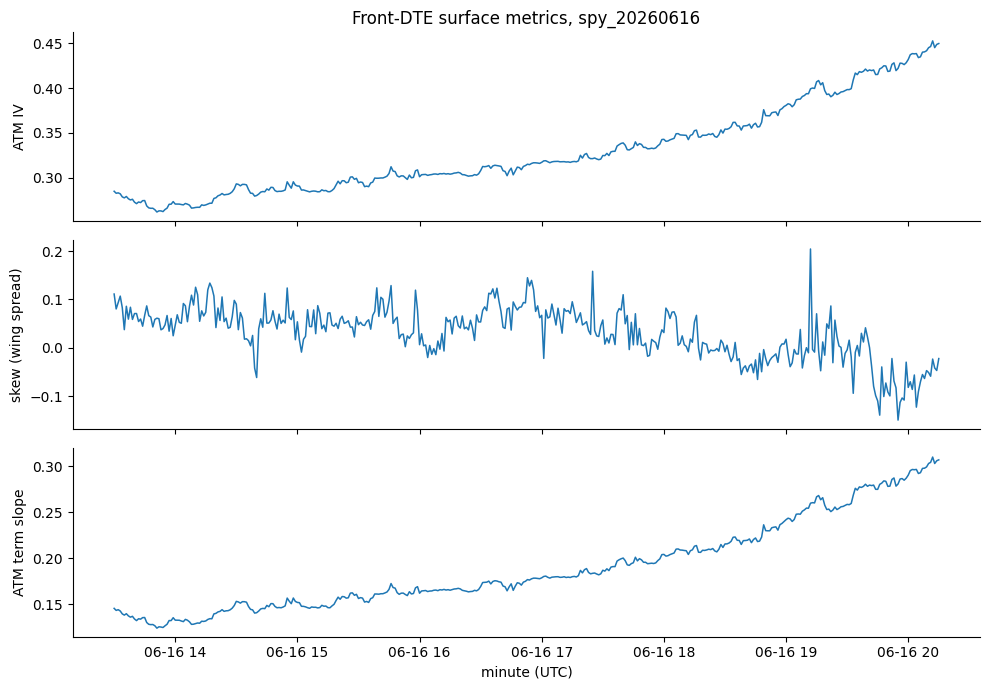

In [5]:
front = metrics.sort_values('dte_bucket').groupby('minute').first().reset_index()
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, col, lab in zip(axes, ['atm_iv', 'skew', 'term_slope_atm'],
                        ['ATM IV', 'skew (wing spread)', 'ATM term slope']):
    ax.plot(front['minute'], front[col], lw=1.1)
    ax.set_ylabel(lab)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_title(f'Front-DTE surface metrics, {DAY}')
axes[2].set_xlabel('minute (UTC)')
plt.tight_layout()

## Fit quality is a first-class output

Every cell carries the SVI slice's trust flag and fit RMSE; untrusted slices
fall back to direct interpolation rather than being silently kept. On the
reference validation day, 85.7% of slices were trusted and put-call parity
recovered a forward for 100% of expiry-minutes.

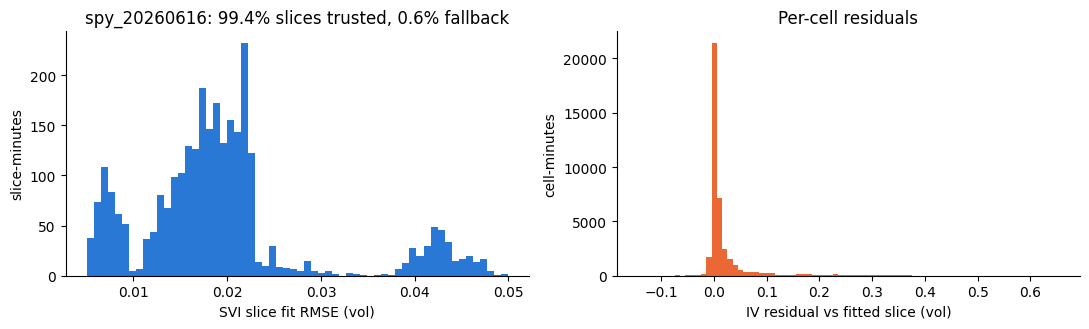

In [6]:
sl = grid.drop_duplicates(['minute', 'dte_bucket'])
trusted = sl['svi_trusted'].mean()
fb = sl['fallback_used'].mean()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(sl['slice_fit_rmse'].dropna(), bins=60, color='#2a78d6')
axes[0].set_xlabel('SVI slice fit RMSE (vol)'); axes[0].set_ylabel('slice-minutes')
axes[0].set_title(f'{DAY}: {trusted:.1%} slices trusted, {fb:.1%} fallback')
res = grid['residual_iv'].dropna()
axes[1].hist(res, bins=80, color='#eb6834')
axes[1].set_xlabel('IV residual vs fitted slice (vol)'); axes[1].set_ylabel('cell-minutes')
axes[1].set_title('Per-cell residuals')
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

## The validation gate

No session enters the research panel without passing an automated battery
(`validate_surface.py`): among quote-eligible contract-minutes the solvable-IV
fraction must be at least 90%; median put-call IV disagreement at most 1.5
vol-points; butterfly-negativity (a static-arbitrage smell) below threshold;
SVI fit RMSE bounds; and an external sanity check of ATM IV against an
independent reference within 3 vol-points. All 21 June sessions passed, and
the panel used in the memo contains only gated sessions.